FFHS_FS26_AnPy_MichaelSchori_Semesterarbeit_Teil1

# Fibonacci-Folge
---

## Einleitung
Das Ziel dieser Arbeit ist es, die Fibonacci-Folge zu untersuchen. Dazu wird eine naive rekursive Berechung, eine Zählung der dabei entstehenden Funktionsaufrufe, einen Vergleich mit den Fibonaaci-Zahlen, ein Timing-Experiment und eine effiziente Implementierung durchgeführt.

## Theoretische Grundlagen

Die Fibonacci-Folge ist rekursiv definiert durch [1]:

$$
F_0 = 0, \quad F_1 = 1, \quad
F_n = F_{n-1} + F_{n-2} \quad (n \geq 2).
$$

Die naive rekursive Implementierung der Funktion `fib(n)` setzt diese Definition unmittelbar um. Für jedes $n \geq 2$ werden dabei zwei weitere rekursive Funktionsaufrufe ausgelöst, nämlich `fib(n-1)` und `fib(n-2)`.

Diese direkte Umsetzung der mathematischen Definition führt dazu, dass identische Teilprobleme mehrfach berechnet werden. Beispielsweise wird bei der Berechnung von $F_5$ der Wert $F_3$ sowohl im Zweig von $F_4$ als auch im Zweig von $F_3$ erneut bestimmt. Allgemein entsteht ein Rekursionsbaum, dessen Knoten die einzelnen Funktionsaufrufe darstellen.

Zur Analyse der Effizienz wird daher nicht nur der berechnete Zahlenwert betrachtet, sondern die Anzahl der Funktionsaufrufe untersucht. Sei $C(n)$ die Anzahl der Aufrufe der Funktion `fib` bei der Berechnung von $F_n$.

Für die Basisfälle gilt:

$$
C(0) = 1, \quad C(1) = 1,
$$

da jeweils genau ein Funktionsaufruf ausgeführt wird.

Für $n \geq 2$ gilt: Jeder Aufruf von `fib(n)` erzeugt zwei rekursive Aufrufe sowie den aktuellen Aufruf selbst. Somit ergibt sich die Rekursionsgleichung

$$
C(n) = 1 + C(n-1) + C(n-2).
$$

Diese Rekursion besitzt dieselbe Struktur wie die Fibonacci-Rekursion, erweitert um einen konstanten Term. Da bei jedem Schritt zwei weitere rekursive Aufrufe entstehen, wächst die Anzahl der Funktionsaufrufe sehr schnell mit zunehmendem $n$. Die Rekursion beschreibt die Anzahl der Knoten im Rekursionsbaum der Funktion `fib`. Da dieser Baum mit wachsendem $n$ stark verzweigt, ist ein exponentielles Wachstum der Funktionsaufrufe zu erwarten. Die theoretische Analyse legt somit nahe, dass die naive rekursive Implementierung eine exponentielle Zeitkomplexität besitzt. Diese Vermutung wird im weiteren Verlauf der Arbeit durch experimentelle Laufzeitmessungen überprüft.

## Implementierungsidee
Für die Aufgabenstellung ist es notwendig, die Fibonacci-Folge zu berechnen und die Anzahl der Funktionsaufrufe zu zählen. Dazu wird eine naive rekursive Implementierung erstellt, die sowohl die Fibonacci-Zahl als auch die Anzahl der Aufrufe zurückgibt. Dadurch kann eine Analyse gemäss Aufgabenstellung erfolgen.

Die folgende Implementierungsidee ist dabei ausschlaggebend.

- Implementation von `fib(n)` als naive rekursive Funktion
- Zählen der Funktionsaufrufe durch separate Funktion `fib_count_calls(n)`
- Laufzeiten mit `time` messen durch separate Funktion `fib_time(n)`
- Implementation von `fib_fast(n)` als effiziente Version durch Iteration

## Programmcode
### Naive rekursive Implementierung

In [49]:
def fib(n: int) -> int:
    """
    Calculates the n-th Fibonacci number using a naive recursive approach.
    :param n: The index of the Fibonacci number to calculate. Must be a non-negative integer.
    :return: The n-th Fibonacci number.
    :raises ValueError: If n is negative.
    """
    if n < 0:
        raise ValueError("Error: n muss >= 0 sein.")
    if n == 0:
        return 0
    if n == 1:
        return 1
    return fib(n - 1) + fib(n - 2)

### Anzahl Funktionsaufrufe zählen

In [50]:
def fib_count_calls(n: int) -> int:
    """
    Counts the number of function calls made by the naive recursive Fibonacci implementation.
    :param n: The index of the Fibonacci number for which to count the function calls. Must be a non-negative integer.
    :return: The total number of function calls made to compute fib(n).
    :raises ValueError: If n is negative.
    """
    if n < 0:
        raise ValueError("Error: n muss >= 0 sein.")
    if n in (0, 1):
        return 1
    return 1 + fib_count_calls(n - 1) + fib_count_calls(n - 2)

### Effiziente Implementierung (iterativ) [2]

In [51]:
def fib_fast(n: int) -> int:
    """
    Calculates the n-th Fibonacci number using an efficient iterative approach.
    :param n: The index of the Fibonacci number to calculate. Must be a non-negative integer.
    :return: The n-th Fibonacci number.
    :raises ValueError: If n is negative.
    """
    if n < 0:
        raise ValueError("Error: n muss >= 0 sein.")
    if n in (0, 1):
        return n
    a, b = 0, 1
    for _ in range(2, n + 1):
        a, b = b, a + b
    return b

### Laufzeitmessung

In [52]:
from time import time


def fib_time(n: int, fib_func) -> float:
    """
    Measures the execution time of a given Fibonacci function for a specific input n with
    the time-function as predetermined in the task description.
    :param n: The index of the Fibonacci number to calculate. Must be a non-negative integer.
    :param fib_func: The Fibonacci function to be timed. Must be a callable that takes a single integer argument.
    :return: The execution time in seconds for the given Fibonacci function to compute fib(n).
    :raises ValueError: If n is negative or if fib_func is not a callable.
    """
    start = time()
    fib_func(n)
    end = time()
    return end - start

## Darstellung der Ergebnisse
### Vergleich von $C(n)$ mit Fibonacci-Zahlen

In [53]:
import pandas as pd

rows = []
for n in range(0, 10):
    fn = fib(n)
    cn = fib_count_calls(n)
    rows.append((n, fn, cn))

df = pd.DataFrame(rows, columns=["n", "fn", "C(n)"])
df

,n,fn,C(n)
0,0,0,1
1,1,1,1
2,2,1,3
3,3,2,5
4,4,3,9
5,5,5,15
6,6,8,25
7,7,13,41
8,8,21,67
9,9,34,109


### Laufzeitvergleich naive vs. effiziente Implementierung

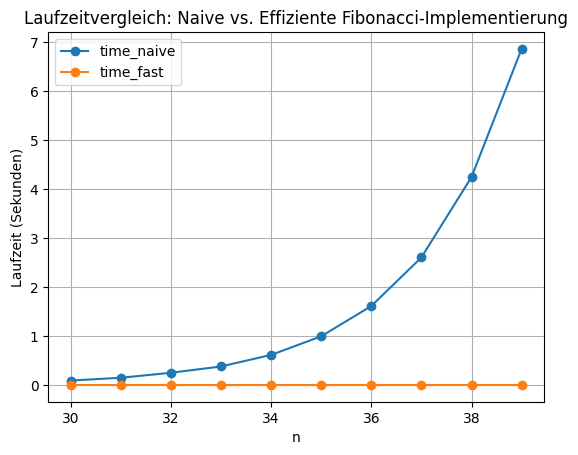

In [54]:
import matplotlib.pyplot as plt

rows = []

for n in range(30, 40):
    time_naive = fib_time(n, fib)
    time_fast = fib_time(n, fib_fast)
    rows.append((n, time_naive, time_fast))

df = pd.DataFrame(rows, columns=["n", "time_naive", "time_fast"])

df.plot(x="n", y=["time_naive", "time_fast"], marker="o")
plt.xlabel("n")
plt.ylabel("Laufzeit (Sekunden)")
plt.title("Laufzeitvergleich: Naive vs. Effiziente Fibonacci-Implementierung")
plt.grid(True)
plt.show()

## Diskussion der Ergebnisse
### Analyse der Aufrufanzahl $C(n)$ im Vergleich zu Fibonacci-Zahlen
Die experimentellen Ergebnisse zeigen, dass $C(n)$ exponentiell wächst. Vergleicht man die Werte von $C(n)$ mit den Fibonacci-Zahlen, erkennt man eine starke Ähnlichkeit. Da die Fibonacci-Zahlen selbst exponentiell wachsen, bestätigt dies die Vermutung, dass die Anzahl der Funktionsaufrufe bei der naiven Implementierung ebenfalls exponentiell wächst. Dies erklärt, warum die naive Implementierung für grössere Werte von n unpraktisch wird.

### Laufzeitvergleich
Die gemessenen Zeiten bestätigen die theoretische Analyse. Während die naive Implementierung exponentiell wächst, zeigt die iterative Implementierung ein annähernd lineares Wachstum. Die exponentielle Laufzeit ist nicht primär ein Speicherproblem, sondern entsteht durch die wiederholte Berechnung identischer Teilprobleme. Die iterative Variante vermeidet diese Redundanz vollständig. Damit wird deutlich, dass mathematische Eleganz nicht automatisch algorithmische Effizienz bedeutet.

### Komplexitätsanalyse
Die naive rekursive Implementierung besitzt eine exponentielle Zeitkomplexität ($T(n) \in O(\varphi^n)$), da die Anzahl der Funktionsaufrufe proportional zu einer Fibonacci-Zahl wächst. Die iterative Implementierung hingegen berechnet jeden Wert genau einmal und besitzt daher eine lineare Zeitkomplexität ($T(n) \in O(n)$). Der Unterschied zwischen exponentiellem und linearem Wachstum erklärt die stark abweichenden Laufzeiten bei grösseren Eingabewerten.

# Schlussfolgerungen und Ausblick
Die naive rekursive Implementierung der Fibonacci-Folge ist konzeptionell einfach und entspricht direkt der mathematischen Definition. Allerdings zeigt die Analyse, dass diese Implementierung algorithmisch ineffizient ist. Die Anzahl der Funktionsaufrufe wächst exponentiell, wodurch die Laufzeit für grössere Werte von $n$ schnell unpraktisch wird.

Die iterative Implementierung reduziert die Laufzeit auf eine lineare Komplexität $O(n)$, da jeder Fibonacci-Wert genau einmal berechnet wird. Dadurch ist sie für grosse Eingabewerte deutlich besser geeignet.

Ein möglicher weiterer Ansatz wäre die Verwendung von Memoisierung. Dabei werden bereits berechnete Werte gespeichert, sodass identische Teilprobleme nicht mehrfach berechnet werden müssen [1]. Eine rekursive Implementierung mit Memoisierung erreicht ebenfalls eine lineare Laufzeit, benötigt jedoch zusätzlichen Speicher.

Darüber hinaus könnten weitere Laufzeituntersuchungen durchgeführt werden, beispielsweise:
- Vergleich zwischen Iteration und Memoisierung
- Analyse des Speicherverbrauchs
- Untersuchung numerischer Stabilität für sehr grosse $n$

## Literaturverzeichnis
[1] T. H. Cormen, Hrsg., Introduction to algorithms, 3. ed. Cambridge, Mass.: MIT Press, 2009.<br>
[2] «Fibonacci Series Program In Python Using Iterative Method», GeeksforGeeks. Zugegriffen: 27. Februar 2026. [Online]. Verfügbar unter: https://www.geeksforgeeks.org/python/fibonacci-series-program-in-python-using-iterative-method/